<a href="https://colab.research.google.com/github/masum-mir/machine-learning-journey/blob/main/KNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    f1_score, precision_score,
    recall_score
)


In [ ]:
# load data
df_raw = pd.read_csv("heart.csv")

print(df_raw.shape)
print(df_raw.head())

df_raw.info()

print(df_raw['target'].value_counts())


(1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null 

Total rows: 1025
Duplicate rows: 723
Unique rows: 302


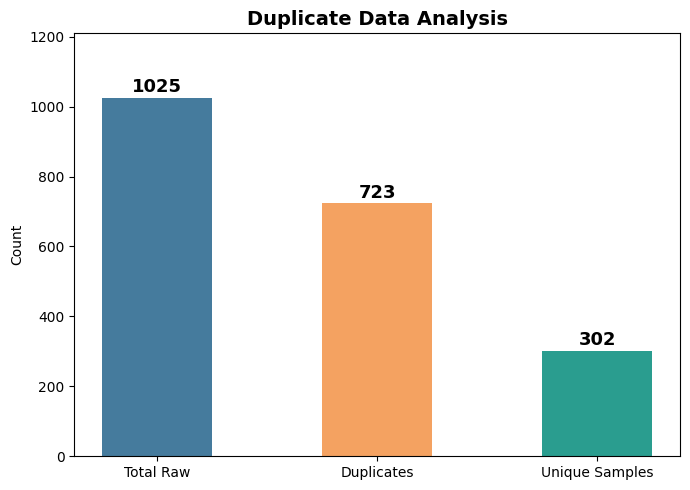


Missing Values: 
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
# Duplicate Analysis
n_raw = len(df_raw)
n_dups = df_raw.duplicated().sum()
df = df_raw.drop_duplicates().reset_index(drop=True)
n_clean = len(df)

print("Total rows:", n_raw)
print("Duplicate rows:", n_dups)
print("Unique rows:", len(df))

plt.figure(figsize=(7,5))

categories = ['Total Raw', 'Duplicates', 'Unique Samples']
values = [n_raw, n_dups, n_clean]
bar_colors = ["#457B9D", '#F4A261', "#2A9D8F"]
bars = plt.bar(categories, values, color=bar_colors, lw=1.5, width=0.5)

for bar, val in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=13)

plt.title('Duplicate Data Analysis', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.ylim(0, max(values) * 1.18)
plt.tight_layout()
plt.savefig("DuplicateDATAAnalysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Missing Values
print("\nMissing Values: ")
print(df.isnull().sum())



In [ ]:
# DESCRIPTIVE STATISTICS
print("Full Descriptive Statistics:")
print(df.describe().T.round(3))


Full Descriptive Statistics:
          count     mean     std    min     25%    50%     75%    max
age       302.0   54.421   9.048   29.0   48.00   55.5   61.00   77.0
sex       302.0    0.682   0.466    0.0    0.00    1.0    1.00    1.0
cp        302.0    0.964   1.032    0.0    0.00    1.0    2.00    3.0
trestbps  302.0  131.603  17.563   94.0  120.00  130.0  140.00  200.0
chol      302.0  246.500  51.753  126.0  211.00  240.5  274.75  564.0
fbs       302.0    0.149   0.357    0.0    0.00    0.0    0.00    1.0
restecg   302.0    0.526   0.526    0.0    0.00    1.0    1.00    2.0
thalach   302.0  149.570  22.904   71.0  133.25  152.5  166.00  202.0
exang     302.0    0.328   0.470    0.0    0.00    0.0    1.00    1.0
oldpeak   302.0    1.043   1.161    0.0    0.00    0.8    1.60    6.2
slope     302.0    1.397   0.616    0.0    1.00    1.0    2.00    2.0
ca        302.0    0.719   1.007    0.0    0.00    0.0    1.00    4.0
thal      302.0    2.315   0.613    0.0    2.00    2.0    3.0

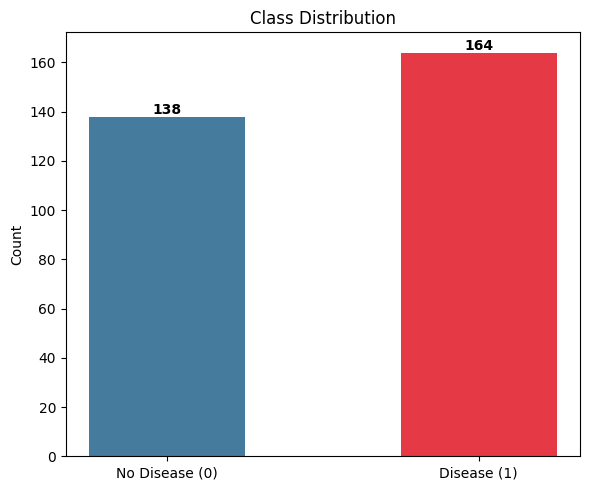

In [ ]:
# CLASS DISTRIBUTION
counts = df['target'].value_counts().sort_index()
labels = ['No Disease (0)', 'Disease (1)']
colors = ["#457B9D", "#E63946"]

plt.figure(figsize=(6,5))
bars = plt.bar(labels, counts.values, color=colors, width=0.5)

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             str(val),
             ha='center', va='bottom', fontweight='bold')
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("ClassDistribution.png", dpi=300, bbox_inches='tight')
plt.show()

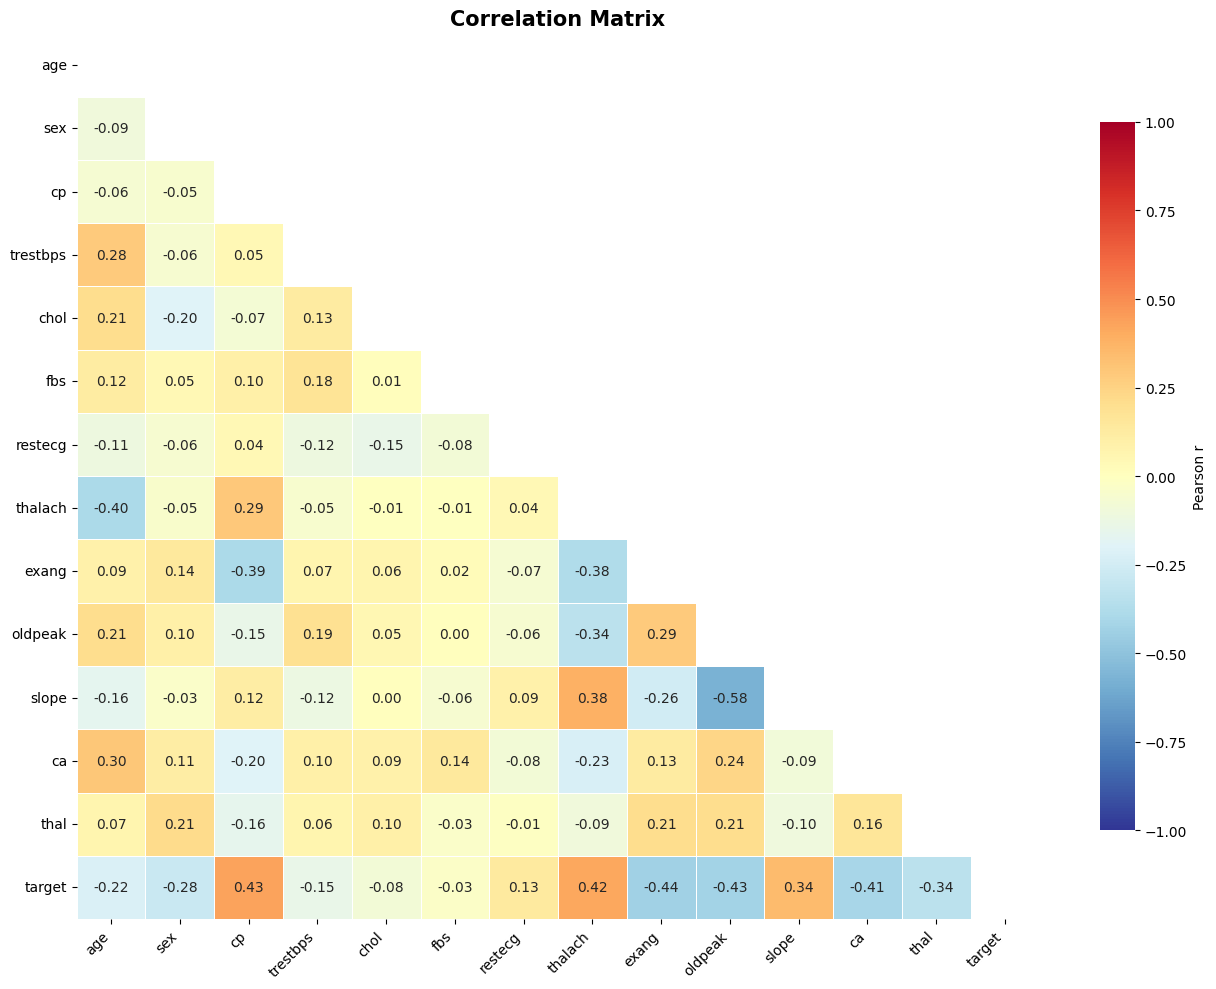

Top 10 Features Correlated with Target: 
exang       0.4356
cp          0.4321
oldpeak     0.4291
thalach     0.4200
ca          0.4090
slope       0.3439
thal        0.3431
sex         0.2836
age         0.2215
trestbps    0.1463
Name: target, dtype: float64


In [ ]:
# CORRELATION ANALYSIS
fig, ax = plt.subplots(figsize=(13, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax,
            vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson r', 'shrink': 0.8})
ax.set_title('Correlation Matrix', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("CorrelationMatrix.png", dpi=300, bbox_inches='tight')
plt.show()

# Top correlations with target
print("Top 10 Features Correlated with Target: ")
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
print(target_corr.round(4).head(10))


In [ ]:
# PREPROCESSING
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

scaled_df = pd.DataFrame(X_train_sc, columns=X.columns)


Best K: 21
CV Accuracy: 0.8420068027210885


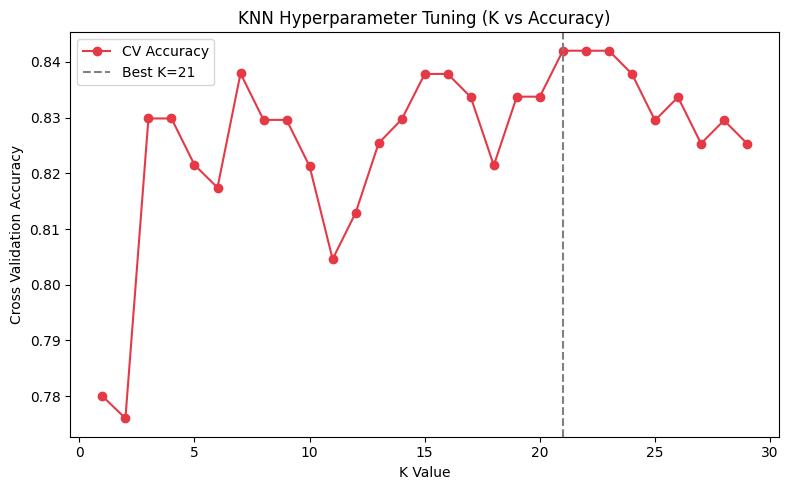

In [ ]:
# KNN Hyperparameter Tuning
k_range = range(1, 30)
cv_scores = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV accuracy for each K
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=skf, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]

print("Best K:", best_k)
print("CV Accuracy:", max(cv_scores))


plt.figure(figsize=(8,5))

plt.plot(k_range, cv_scores, 'o-', color="#E63946", label='CV Accuracy')
plt.axvline(best_k, color='gray', linestyle='--', label=f'Best K={best_k}')

plt.title('KNN Hyperparameter Tuning (K vs Accuracy)')
plt.xlabel('K Value')
plt.ylabel('Cross Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig("KNNHyperparameterTuning.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# TRAIN FINAL KNN MODEL
model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8524590163934426


In [ ]:
# CLASSIFICATION METRICS
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"  FINAL KNN MODEL RESULTS  (K = {best_k})\n")
print(f"  Accuracy   : {acc:.4f}")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")


  FINAL KNN MODEL RESULTS  (K = 21)

  Accuracy   : 0.8525
  Precision  : 0.8333
  Recall     : 0.9091
  F1-Score   : 0.8696


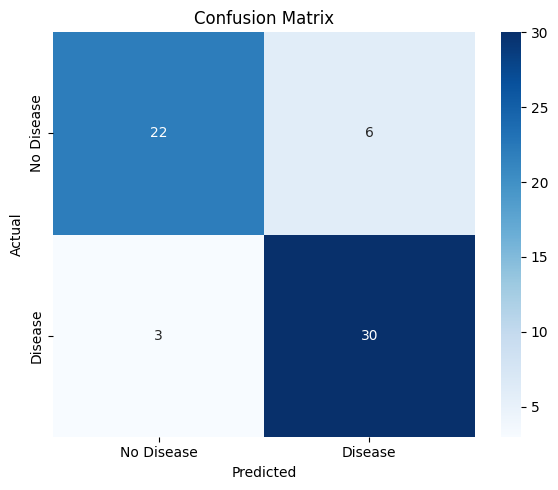

In [ ]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig("ConfusionMatrix.png", dpi=300, bbox_inches='tight')
plt.show()
